<a href="https://colab.research.google.com/github/studentradhika/Adaptive-Behavioral-Intelligence-System-for-Resource-Utilization-Optimization/blob/main/Before%20workload.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check GPU Availability
!nvidia-smi


Wed Feb 18 09:15:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install gputil pandas torch torchvision matplotlib


  Preparing metadata (setup.py) ... done
  Created wheel for gputil: filename=GPUtil-1.4.0-py3-none-any.whl size=7392 sha256=46d866467ac53d7211b12d6d1507cb75398ed4eaa8ac44655937faf5c991146b
  Stored in directory: /root/.cache/pip/wheels/92/a8/b7/d8a067c31a74de9ca252bbe53dea5f896faabd25d55f541037
Successfully built gputil


In [ ]:
import GPUtil
import time
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from datetime import datetime


In [ ]:
data_list = []

print("Starting BEFORE Stress Monitoring...")

for i in range(15):
    gpus = GPUtil.getGPUs()
    for gpu in gpus:
        data = {
            "Time": datetime.now().strftime("%H:%M:%S"),
            "GPU Name": gpu.name,
            "Memory Used (MB)": gpu.memoryUsed,
            "Memory Total (MB)": gpu.memoryTotal,
            "Temperature (C)": gpu.temperature,
            "Load (%)": gpu.load * 100
        }
        data_list.append(data)
        print(data)

    time.sleep(2)

df_before = pd.DataFrame(data_list)
df_before.to_csv("before_stress.csv", index=False)

print("Before Stress Data Saved!")


Starting BEFORE Stress Monitoring...
{'Time': '09:17:01', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 0.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 44.0, 'Load (%)': 0.0}
{'Time': '09:17:03', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 0.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 44.0, 'Load (%)': 0.0}
{'Time': '09:17:05', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 0.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 44.0, 'Load (%)': 0.0}
{'Time': '09:17:07', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 0.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 44.0, 'Load (%)': 0.0}
{'Time': '09:17:09', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 0.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 44.0, 'Load (%)': 0.0}
{'Time': '09:17:11', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 0.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 44.0, 'Load (%)': 0.0}
{'Time': '09:17:13', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 0.0, 'Memory Total (MB)': 15360.0, 'Temperatur

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                       download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=512, shuffle=True)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 512),
    nn.ReLU(),
    nn.Linear(512, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

print("Starting Stress Training...")

for epoch in range(3):
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("Stress Completed!")


100%|██████████| 170M/170M [00:03<00:00, 49.5MB/s]


Starting Stress Training...
Stress Completed!


In [ ]:
data_list = []

print("Starting AFTER Stress Monitoring...")

for i in range(15):
    gpus = GPUtil.getGPUs()
    for gpu in gpus:
        data = {
            "Time": datetime.now().strftime("%H:%M:%S"),
            "GPU Name": gpu.name,
            "Memory Used (MB)": gpu.memoryUsed,
            "Memory Total (MB)": gpu.memoryTotal,
            "Temperature (C)": gpu.temperature,
            "Load (%)": gpu.load * 100
        }
        data_list.append(data)
        print(data)

    time.sleep(2)

df_after = pd.DataFrame(data_list)
df_after.to_csv("after_stress.csv", index=False)

print("After Stress Data Saved!")


Starting AFTER Stress Monitoring...
{'Time': '09:18:58', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 205.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 52.0, 'Load (%)': 0.0}
{'Time': '09:19:00', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 205.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 52.0, 'Load (%)': 0.0}
{'Time': '09:19:02', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 205.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 52.0, 'Load (%)': 0.0}
{'Time': '09:19:04', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 205.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 52.0, 'Load (%)': 0.0}
{'Time': '09:19:06', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 205.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 52.0, 'Load (%)': 0.0}
{'Time': '09:19:08', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 205.0, 'Memory Total (MB)': 15360.0, 'Temperature (C)': 53.0, 'Load (%)': 0.0}
{'Time': '09:19:10', 'GPU Name': 'Tesla T4', 'Memory Used (MB)': 205.0, 'Memory Total (MB)': 15360.0

In [ ]:
print("Before Avg Load:", df_before["Load (%)"].mean())
print("After Avg Load:", df_after["Load (%)"].mean())

print("Before Avg Temp:", df_before["Temperature (C)"].mean())
print("After Avg Temp:", df_after["Temperature (C)"].mean())


Before Avg Load: 0.0
After Avg Load: 0.0
Before Avg Temp: 44.0
After Avg Temp: 52.93333333333333


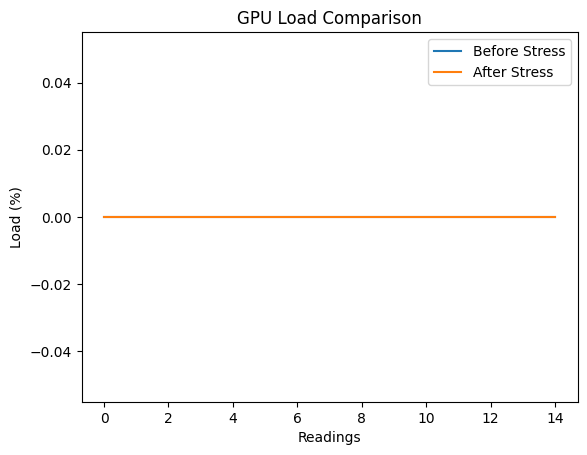

In [ ]:
plt.plot(df_before["Load (%)"], label="Before Stress")
plt.plot(df_after["Load (%)"], label="After Stress")
plt.legend()
plt.title("GPU Load Comparison")
plt.xlabel("Readings")
plt.ylabel("Load (%)")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df_before.to_csv('/content/drive/MyDrive/before_stress.csv', index=False)
df_after.to_csv('/content/drive/MyDrive/after_stress.csv', index=False)

print("Files Saved to Google Drive Successfully!")


MessageError: Error: credential propagation was unsuccessful